In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.integrate import odeint
from rodeo.ode import interrogate_rodeo, interrogate_chkrebtii, interrogate_tronarp, interrogate_schober, solve_mv
from rodeo.fenrir import *
from rodeo.ibm import ibm_init
from jaxopt import ScipyMinimize, BFGS, LBFGS
from jax import jacfwd, jacrev
from double_filter import loglikehood, solve_mv_nn, loglikehood_nn
import fenrir_filter as ff
import double_filter as df
import double_filter2 as df2
from jax.config import config

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from theta_plot import theta_plotsingle, theta_plot
config.update("jax_enable_x64", True)
import warnings
from jax.config import config
warnings.filterwarnings('ignore')
from diffrax import diffeqsolve, Dopri5, Dopri8, ODETerm, PIDController, SaveAt, ConstantStepSize

In [29]:
def fitz0(X_t, t, theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

def ode_fun(X, t, theta):
    "FitzHugh-Nagumo ODE function for jax."
    a, b, c = theta
    p = len(X)//2
    V, R = X[0], X[p]
    return jnp.array([c*(V - V*V*V/3 + R),
                      -1/c*(V - a + b*R)])

def fitz(X_t, t, theta):
    "Fitz ODE written for jax"
    a, b, c = theta
    V, R = X_t[:, 0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                      [-1/c*(V - a + b*R)]])


In [2]:
def x0_initialize(phi, x0):
    r"Initialize x0 for none missing initial values"
    j = 0
    for ind in range(len(phi)):
        x0 = x0.at[ind,0].set(phi[j])
        j+=1
    return x0
def logprior(x, mean, sd):
    r"Calculate the loglikelihood of the normal distribution."
    return jnp.sum(jsp.stats.norm.logpdf(x=x, loc=mean, scale=sd))

def rax_fun(t, X_t, theta):
    "Fitz ODE written for diffrax"
    a, b, c = theta
    p = len(X_t)//2
    V, R = X_t[0], X_t[p]
    return jnp.array([c*(V - V*V*V/3 + R),
                        -1/c*(V - a + b*R)])

In [31]:
# problem setup and intialization
n_deriv = 3  # Total state
n_var = 2  # Total measures
n_dim = 2

# it is assumed that the solution is sought on the interval [tmin, tmax].
n_steps = 200
tmin = 0.
tmax = 40.
theta = np.array([0.2, 0.2, 3])
thetaj = jnp.array(theta)

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = 10
sigma = jnp.array([sigma]*n_var)

# Initial x0 for odeint
ode0 = np.array([-1., 1.])

# Initial x0 for jax
x0_block = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])

W = jnp.array([[[0., 1., 0.]], [[0., 1., 0.]]])  # ODE LHS matrix
key = jax.random.PRNGKey(0)

# observations
n_obs = 40
tseq1 = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(fitz0, ode0, tseq1, args=(theta,))
gamma = np.sqrt(0.005)
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t
y_obs = jnp.expand_dims(obs, -1)
trans_obs = jnp.array([[[1., 0., 0.]], [[1., 0., 0.]]])
mean_obs = jnp.zeros((2, 1))
var_obs = gamma**2*jnp.array([[[1.]],[[1.]]])
def g2(x_obs, y_curr):
    n_block = y_curr.shape[0]
    return jnp.sum(jax.vmap(lambda b: jsp.stats.multivariate_normal.logpdf(y_curr[b], x_obs[b], var_obs[b]))(jnp.arange(n_block)))

# jit double filter
df_jit = jax.jit(fenrir, static_argnums=(1, 7))

In [5]:
# exp likelihood
# observations
n_obs = 40
tseq1 = np.linspace(tmin, tmax, n_obs+1)
exact1 = odeint(fitz0, ode0, tseq1, args=(theta,))
b0 = 0.1
b1 = 0.5
obs = np.random.default_rng(0).poisson(lam = jnp.exp(b0+b1*exact1))
trans_obs = jnp.array([[[1., 0., 0.]], [[1., 0., 0.]]])
y_obs = jnp.expand_dims(obs, -1)

def g2(x_obs, y_curr):
    n_block = y_curr.shape[0]
    b0 = 0.1
    b1 = 0.5
    return jnp.sum(jax.vmap(lambda b: jsp.stats.poisson.logpmf(y_curr[b], jnp.exp(b0+b1*x_obs[b])))(jnp.arange(n_block)))


In [32]:
# Get parameters for non block
n_res = 10
n_steps = n_obs*n_res
sigma = 12
sigma = jnp.array([sigma]*n_var)
dt = (tmax-tmin)/n_steps
n_order = jnp.array([n_deriv]*n_var)
ode_init = ibm_init(dt, n_order, sigma)

In [33]:
import double_filter as df
double_m, double_v = df.solve_mv(key, fitz,  W, x0_block, thetaj, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)

In [34]:
fenrir_m, _ = ff.fenrir_filter(key, fitz,  W, x0_block, thetaj, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)

In [35]:
om, _= solve_mv(key, fitz, W, x0_block, theta,
         tmin, tmax, n_steps,
         **ode_init, interrogate=interrogate_tronarp)

In [13]:
double_m, double_v = df2.solve_mv_nn(key, fitz,  W, x0_block, thetaj, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            g2, trans_obs, y_obs, interrogate_tronarp)

In [37]:
fenrir(key, fitz, W, x0_block, thetaj, tmin, tmax, n_res,
    ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
    trans_obs, mean_obs, var_obs, y_obs, interrogate_rodeo)

DeviceArray(-13.55452468, dtype=float64)

In [19]:
loglikehood(key, fitz, W, x0_block, thetaj, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            trans_obs, mean_obs, var_obs, y_obs, interrogate_rodeo)

DeviceArray(nan, dtype=float64)

In [36]:
tseq_sim = np.linspace(tmin, tmax, n_steps+1)
exact_sim = odeint(fitz0, ode0, tseq_sim, args=(theta,))

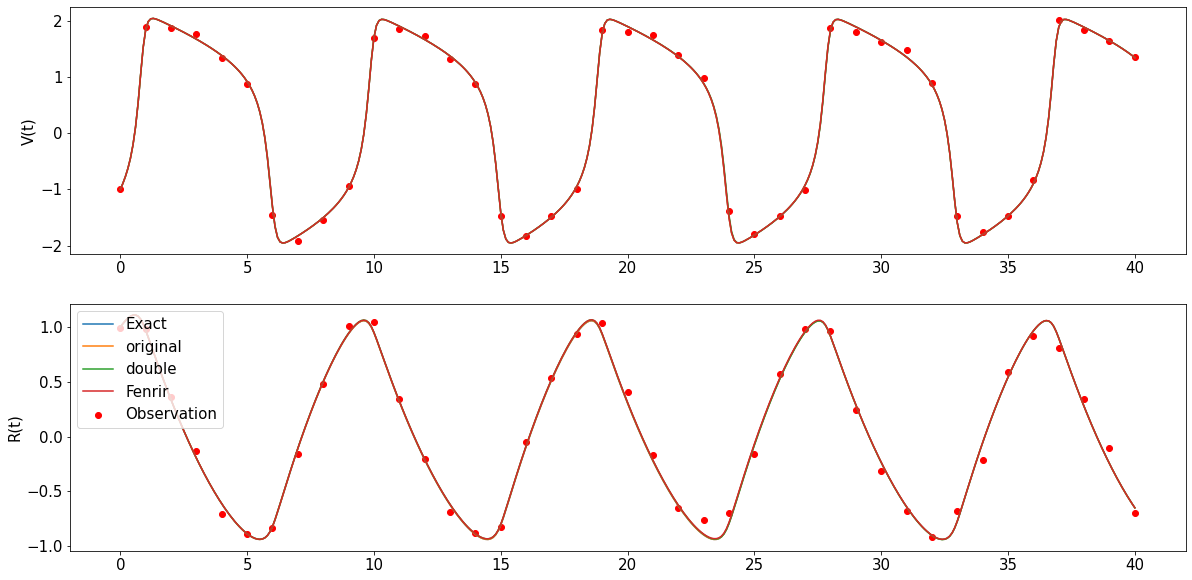

In [37]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(n_var, 1, figsize=(20, 10))
y_label = ['V(t)', 'R(t)']
plt.rcParams.update({'font.size': 15})
for i in range(n_var):
    axs[i].set_ylabel(y_label[i])
    axs[i].plot(tseq_sim, exact_sim[:, i], label='Exact')
    # axs[i].plot(tseq_sim, z_out['state_filt'][0][:,i, 0], label="Origial")
    # axs[i].plot(tseq_sim, zy_out['state_filt'][0][:, i, 0], label="double")
    axs[i].plot(tseq_sim, om[:, i, 0], label="original")
    axs[i].plot(tseq_sim, double_m[:, i, 0], label="double")
    axs[i].plot(tseq_sim, fenrir_m[:, i, 0], label="Fenrir")
    axs[i].scatter(tseq1, obs[:, i], label='Observation', color='red')
axs[1].legend(loc='upper left')

In [16]:

# logprior parameters
theta_true = jnp.array([0.2, 0.2, 3]) # True theta
n_phi = 5
phi_mean = jnp.zeros(n_phi)
phi_sd = jnp.log(10)*jnp.ones(n_phi) 
n_theta = 3
n_samples = 100000

In [17]:
saveat = SaveAt(ts = tseq1)
term = ODETerm(rax_fun)
# stepsize = PIDController(rtol=1e-20, atol=1e-10)
stepsize_controller = ConstantStepSize()
solver = Dopri8()
diff_dt0 = .1

In [19]:
phi_init = jnp.append(jnp.log(theta_true), ode0)
phi_hat, phi_var = phi_fit(phi_init, jnp.zeros((2,1)), diffrax_nlpost)
theta_diffrax = phi_sample(phi_hat, phi_var, n_samples)
theta_diffrax[:, :n_theta] = np.exp(theta_diffrax[:, :n_theta])

In [36]:
def g(x_t, y_t):
    b0 = 0.1
    b1 = 0.5
    return jnp.sum(jsp.stats.poisson.logpmf(y_t, jnp.exp(b0+b1*x_t)))
    
def double_nlpost(phi, x0):
    n_phi = len(phi_mean)
    x0 = x0_initialize(phi[n_theta:], x0)
    theta = jnp.exp(phi[:n_theta])
    v0 = fitz(x0, 0, theta)
    x0 = jnp.hstack([x0, v0, jnp.zeros(shape=(x0.shape))])
    lp = loglikehood(key, fitz, W, x0, theta, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp

def fenrir_nlpost(phi, x0):
    n_phi = len(phi_mean)
    x0 = x0_initialize(phi[n_theta:], x0)
    theta = jnp.exp(phi[:n_theta])
    v0 = fitz(x0, 0, theta)
    X_0 = jnp.hstack([x0, v0, jnp.zeros(shape=(x0.shape))])
    lp = fenrir(key, fitz, W, X_0, theta, tmin, tmax, n_res,
                ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp

def diffrax_nlpost(phi, x0):
    r"Compute the negative loglikihood of :math:`Y_t` using a deterministic solver."
    n_phi = len(phi_mean)
    x0 = x0_initialize(phi[n_theta:], x0)
    x0 = x0.flatten()
    theta = jnp.exp(phi[:n_theta])
    X_t = diffeqsolve(term, solver, args = theta, t0=tmin, t1=tmax, dt0 = diff_dt0, 
                        y0=jnp.array(x0), saveat=saveat, stepsize_controller=stepsize_controller).ys
    # lp = g(X_t, y_obs.reshape((41, -1)))
    lp = logprior(obs, X_t, gamma)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp
    
def phi_fit(phi_init, x0, obj_fun):
    r"""Compute the optimized :math:`\log{\theta}` and its variance given 
        :math:`Y_t`."""
    
    n_phi = len(phi_init)
    # obj_fun = jax.jit(obj_fun)
    hes = jacfwd(jacrev(obj_fun))
    solver = ScipyMinimize(method="Newton-CG", fun = obj_fun)
    opt_res = solver.run(phi_init, x0)
    phi_hat = opt_res.params
    phi_fisher = hes(phi_hat, x0)
    phi_var = jsp.linalg.solve(phi_fisher, jnp.eye(n_phi))
    # phi_cho, low = jsp.linalg.cho_factor(phi_fisher)
    # phi_var = jsp.linalg.cho_solve((phi_cho, low), jnp.eye(n_phi))
    return phi_hat, phi_var
    
def phi_sample(phi_hat, phi_var, n_samples):
    r"""Simulate :math:`\theta` given the :math:`\log{\hat{\theta}}` 
        and its variance."""
    phi = np.random.default_rng(12345).multivariate_normal(phi_hat, phi_var, n_samples)
    return phi


In [153]:
# Get parameters for non block
n_res = 4
n_steps = n_obs*n_res
dt = (tmax-tmin)/n_steps
sigma = 10
sigma = jnp.array([sigma]*n_var)
n_order = jnp.array([n_deriv]*n_var)
ode_init = ibm_init(dt, n_order, sigma)

In [154]:
phi_init = jnp.append(jnp.log(theta_true), ode0)
phi_hat, phi_var = phi_fit(phi_init, jnp.zeros((2,1)), double_nlpost)
theta_double = np.zeros((1, n_samples, 5))
theta_double[0] = phi_sample(phi_hat, phi_var, n_samples)
theta_double[0, :, :n_theta] = np.exp(theta_double[0, :, :n_theta])

In [155]:
phi_init = jnp.append(jnp.log(theta_true), ode0)
phi_hat, phi_var = phi_fit(phi_init, jnp.zeros((2,1)), fenrir_nlpost)
theta_fenrir = np.zeros((1, n_samples, 5))
theta_fenrir[0] = phi_sample(phi_hat, phi_var, n_samples)
theta_fenrir[0, :, :n_theta] = np.exp(theta_fenrir[0, :, :n_theta])

In [156]:
# plt.rcParams.update({'font.size': 20})
var_names = ['a', 'b', 'c', r"$V(0)$", r"$R(0)$"]
param_true = np.append(theta_true, np.array([-1, 1]))
# theta_fenrir = np.load('saves/fitz_theta_fenrir.npy')

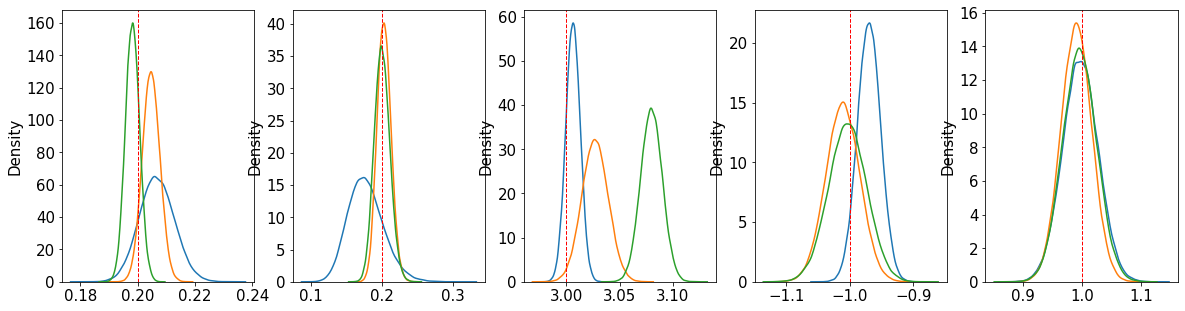

In [157]:
import matplotlib.pyplot as plt
param_true = np.append(theta_true, ode0)
_, axs = plt.subplots(1, 5, figsize=(20,5))
for i in range(5):
    sns.kdeplot(theta_diffrax[:, i], ax=axs[i])
    sns.kdeplot(theta_double[0, :, i], ax=axs[i])
    sns.kdeplot(theta_fenrir[0, :, i], ax=axs[i])
    axs[i].axvline(x=param_true[i], linewidth=1, color='r', linestyle='dashed')

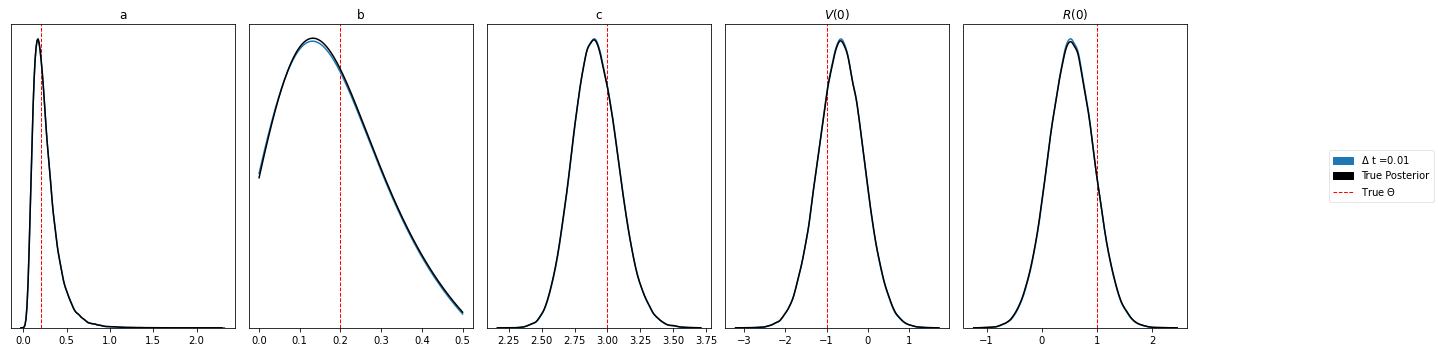

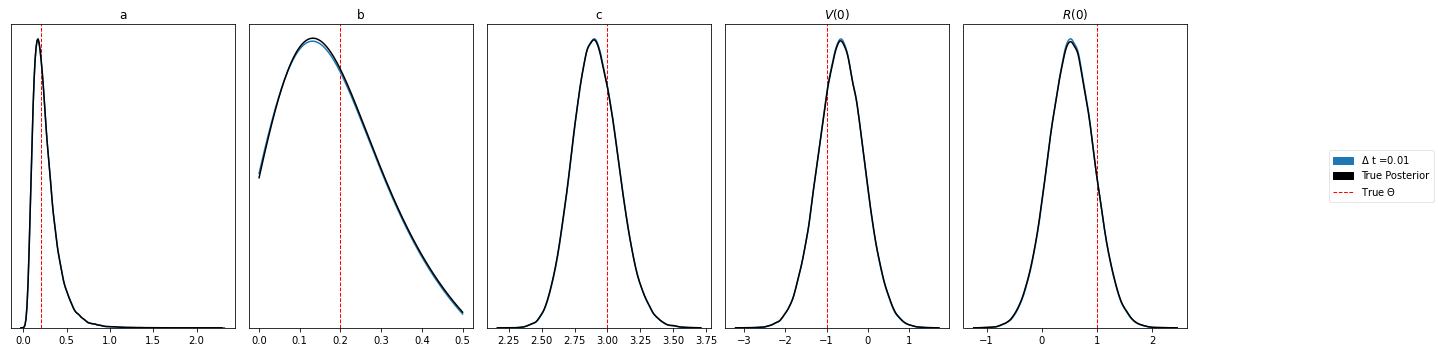

In [28]:
theta_plotsingle(theta_double, theta_diffrax, param_true, [1/100], var_names, clip=[None, (0, 0.5), None, None, None], rows=1)

In [ ]:
theta_plot(theta_double, theta_fenrir, None, None, theta_diffrax, param_true, [1/10], var_names, clip=[None, (0, 0.5), None, None, None], rows=1)

In [5]:
# ODE function
def lorenz(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t[:,0]
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([[dx], [dy], [dz]])

def lorenz0(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return np.array([dx, dy, dz])

# problem setup and intialization
n_deriv = 3  # Total state; q
n_var = 3  # Total observations

# Time interval on which a solution is sought.
tmin = 0.
tmax = 20.
theta = jnp.array([28, 10, 8/3])

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for jax block
x0_block = jnp.array([[-12., 70., 0.], [-5., 125, 0.], [38., -124/3, 0.]])
n_order = jnp.array([n_deriv]*n_var)

# Initial x0 for odeint
ode0 = jnp.array([-12., -5., 38.])

# Get exact solutions for the Lorenz System
n_obs = 20
tseq = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(lorenz0, ode0, tseq, args=(theta,), rtol=1e-20)
gamma = np.sqrt(0.005)
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t


In [6]:
y_obs = jnp.expand_dims(obs, -1)
mean_obs = jnp.zeros((n_var, 1))
trans_obs = np.zeros((n_var, 1, n_deriv))
trans_obs[:, :, 0] = 1
trans_obs = jnp.array(trans_obs)
var_obs = gamma**2*jnp.ones((n_var, 1, 1))
n_res = 200
sigma = 5e7
sigma = jnp.array([sigma]*n_var)
n_steps = n_res*n_obs
dt = (tmax-tmin)/n_steps
ode_init = ibm_init(dt, n_order, sigma)
key = jax.random.PRNGKey(0)

In [7]:
# theta2 = jnp.exp(phi_hat)
double_m, double_v = df.solve_mv(key, lorenz, W_block, x0_block, theta, tmin, tmax, n_res,
                                ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                                trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)

In [8]:
fenrir_m, _ = ff.fenrir_filter(key, lorenz, W_block, x0_block, theta, tmin, tmax, n_res,
                                ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                                trans_obs, mean_obs, var_obs, y_obs, interrogate=interrogate_tronarp)

In [9]:
tseq_sim = np.linspace(tmin, tmax, n_steps+1)
exact_sim = odeint(lorenz0, ode0, tseq_sim, args=(theta,), rtol=1e-20)

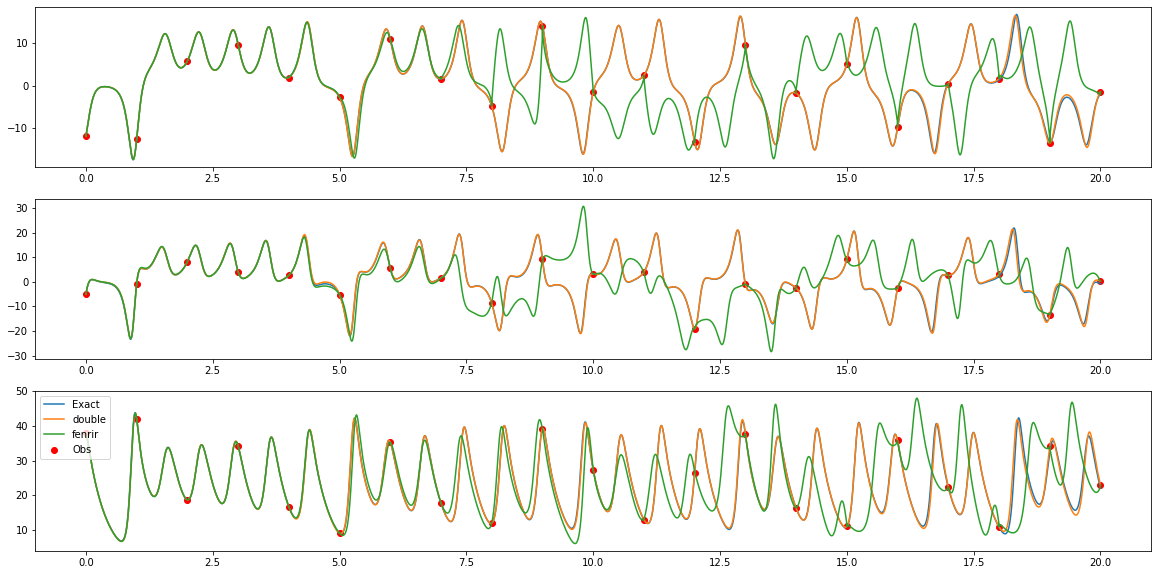

In [10]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_var, 1, figsize=(20, 10))
ylabel = ['x', 'y', 'z']

for i in range(n_var):
    axs[i].plot(tseq_sim, exact_sim[:, i], label='Exact')
    axs[i].plot(tseq_sim, double_m[:, i, 0], label="double")
    axs[i].plot(tseq_sim, fenrir_m[:, i, 0], label="fenrir")
    # axs[i].plot(tseq_sim, X_t[:, i], label="diffrax")
    
    axs[i].scatter(tseq, obs[:, i], label='Obs', color='red')
axs[i].legend(loc='upper left')

In [72]:
# logprior parameters
theta_true = jnp.array([28, 10, 8/3]) # True theta
n_phi = 6
phi_mean = jnp.zeros(n_phi)
phi_sd = jnp.log(10)*jnp.ones(n_phi) 
n_theta = 3
n_samples = 100000

In [73]:
def double_nlpost(phi, x0):
    n_phi = len(phi_mean)
    # x0 = x0_initialize(phi[n_theta:], x0)
    x0 = x0.at[:, 0].set(phi[n_theta:])
    theta = jnp.exp(phi[:n_theta])
    v0 = lorenz(x0, 0, theta)
    x0 = jnp.hstack([x0, v0, jnp.zeros(shape=(x0.shape))])
    lp = loglikehood(key, lorenz, W_block, x0, theta, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp

def fenrir_nlpost(phi, x0):
    n_phi = len(phi_mean)
    # x0 = x0_initialize(phi[n_theta:], x0)
    x0 = x0.at[:, 0].set(phi[n_theta:])
    theta = jnp.exp(phi[:n_theta])
    v0 = lorenz(x0, 0, theta)
    x0 = jnp.hstack([x0, v0, jnp.zeros(shape=(x0.shape))])
    lp = fenrir(key, lorenz, W_block, x0, theta, tmin, tmax, n_res,
                ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp

def phi_fit(phi_init, x0, obj_fun):
    r"""Compute the optimized :math:`\log{\theta}` and its variance given 
        :math:`Y_t`."""
    
    n_phi = len(phi_init)
    hes = jax.jit(jacfwd(jacrev(obj_fun)))
    solver = ScipyMinimize(method="Newton-CG", fun = obj_fun)
    opt_res = solver.run(phi_init, x0)
    phi_hat = opt_res.params
    phi_fisher = hes(phi_hat, x0)
    phi_var = jsp.linalg.solve(phi_fisher, jnp.eye(n_phi))
    return phi_hat, phi_var
    
def phi_sample(phi_hat, phi_var, n_samples):
    r"""Simulate :math:`\theta` given the :math:`\log{\hat{\theta}}` 
        and its variance."""
    phi = np.random.default_rng(12345).multivariate_normal(phi_hat, phi_var, n_samples)
    return phi

In [29]:
def double_nlpost(phi, x0):
    n_phi = len(phi_mean)
    theta = jnp.exp(phi[:n_theta])
    sigma = phi[-1]
    var_state = sigma**2*ode_init['var_state']
    lp = loglikehood(key, lorenz, W_block, x0, theta, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], var_state,
            trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp

def fenrir_nlpost(phi, x0):
    n_phi = len(phi_mean)
    theta = jnp.exp(phi[:n_theta])
    sigma = phi[-1]
    var_state = sigma**2*ode_init['var_state']
    lp = fenrir(key, lorenz, W_block, x0, theta, tmin, tmax, n_res,
                ode_init['trans_state'], ode_init['mean_state'], var_state,
                trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi[:n_phi], phi_mean, phi_sd)
    return -lp

In [74]:
# Get parameters for non block
n_res = 200
sigma = 5e7
sigma = jnp.array([sigma]*n_var)
n_steps = n_res*n_obs
dt = (tmax-tmin)/n_steps
ode_init = ibm_init(dt, n_order, sigma)
key = jax.random.PRNGKey(0)

In [237]:
phi_init = jnp.append(jnp.zeros((3))-2, jnp.array([1]))
solver = ScipyMinimize(method="Newton-CG", fun = fenrir_nlpost)
opt_res = jax.jit(solver.run)(phi_init, x0_block)

In [25]:
saveat = SaveAt(ts = tseq)
term = ODETerm(rax_fun)
# stepsize = PIDController(rtol=1e-20, atol=1e-10)
stepsize = ConstantStepSize()
solver = Dopri8()

In [75]:
phi_init = jnp.append(jnp.log(theta)-0.01, ode0)
phi_hat, phi_var = phi_fit(phi_init, jnp.zeros((3,1)), double_nlpost)
theta_double = np.zeros((1, n_samples, n_phi))
theta_double[0] = phi_sample(phi_hat, phi_var, n_samples)
theta_double[0, :, :n_theta] = np.exp(theta_double[0, :, :n_theta])

In [78]:
phi_init = jnp.append(jnp.log(theta)-0.01, ode0)
phi_hat, phi_var = phi_fit(phi_init, jnp.zeros((3,1)), fenrir_nlpost)
theta_fenrir = phi_sample(phi_hat, phi_var, n_samples)
theta_fenrir[:, :n_theta] = np.exp(theta_fenrir[:, :n_theta])

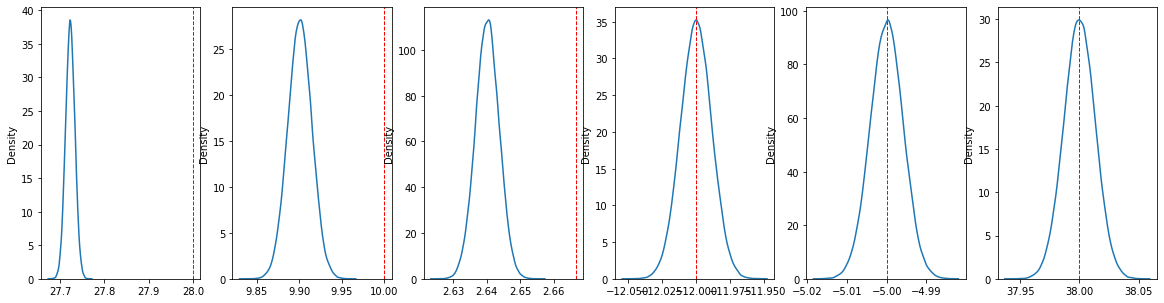

In [79]:
import matplotlib.pyplot as plt
param_true = np.append(theta_true, ode0)
_, axs = plt.subplots(1, 6, figsize=(20,5))
for i in range(6):
    # sns.kdeplot(theta_double[0, :, i], ax=axs[i])
    # sns.kdeplot(theta_diffrax[:, i], ax=axs[i])
    sns.kdeplot(theta_fenrir[:, i], ax=axs[i])
    axs[i].axvline(x=param_true[i], linewidth=1, color='r', linestyle='dashed')

In [ ]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(1, n_var, figsize=(10,5))
for i in range(3):
    # sns.kdeplot(theta_diffrax[:, i], ax=axs[i])
    sns.kdeplot(theta_double[0, :, i], ax=axs[i])
    # sns.kdeplot(theta_fenrir[:, i], ax=axs[i])
    axs[i].axvline(x=theta_true[i], linewidth=1, color='r', linestyle='dashed')